<a href="https://colab.research.google.com/github/AceRb6/Modelos_Econometricos/blob/main/PME04_An%C3%A1lisis_de_los_supuestos_de_los_modelos_clasicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "vgsales.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "gregorut/videogamesales",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_9455/6731088.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 381k/381k [00:00<00:00, 1.01MB/s]

Extracting zip of vgsales.csv...


First 5 records:    Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  


# **1. Carga e inspección estructural**

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Inspección básica
print(f"Dimensiones: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nPrimeras 5 filas:\n{df.head()}")

Dimensiones: (16598, 11)

Tipos de datos:
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

Primeras 5 filas:
   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.

# **2. Valores faltantes**

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje': missing_pct})
print(missing_df[missing_df['Faltantes'] > 0])

           Faltantes  Porcentaje
Year             271    1.632727
Publisher         58    0.349440


#**3. Estadísticas descriptivas (variables numéricas)**


In [ ]:
numeric_cols = ['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
print(df[numeric_cols].describe())

               Year      NA_Sales      EU_Sales      JP_Sales   Other_Sales  \
count  16327.000000  16598.000000  16598.000000  16598.000000  16598.000000   
mean    2006.406443      0.264667      0.146652      0.077782      0.048063   
std        5.828981      0.816683      0.505351      0.309291      0.188588   
min     1980.000000      0.000000      0.000000      0.000000      0.000000   
25%     2003.000000      0.000000      0.000000      0.000000      0.000000   
50%     2007.000000      0.080000      0.020000      0.000000      0.010000   
75%     2010.000000      0.240000      0.110000      0.040000      0.040000   
max     2020.000000     41.490000     29.020000     10.220000     10.570000   

       Global_Sales  
count  16598.000000  
mean       0.537441  
std        1.555028  
min        0.010000  
25%        0.060000  
50%        0.170000  
75%        0.470000  
max       82.740000  


#**4. Detección de outliers: métodos cuantitativos**

In [ ]:
def outlier_summary(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[column] < lower) | (df[column] > upper)).sum()
    return {'IQR': IQR, 'Límite inf': lower, 'Límite sup': upper, 'Outliers (IQR)': n_outliers}

for col in ['Year', 'Global_Sales']:
    print(f"\n{col}: {outlier_summary(df, col)}")


Year: {'IQR': np.float64(7.0), 'Límite inf': np.float64(1992.5), 'Límite sup': np.float64(2020.5), 'Outliers (IQR)': np.int64(305)}

Global_Sales: {'IQR': np.float64(0.41), 'Límite inf': np.float64(-0.5549999999999999), 'Límite sup': np.float64(1.085), 'Outliers (IQR)': np.int64(1893)}


#**5. Visualización de distribuciones y outliers**

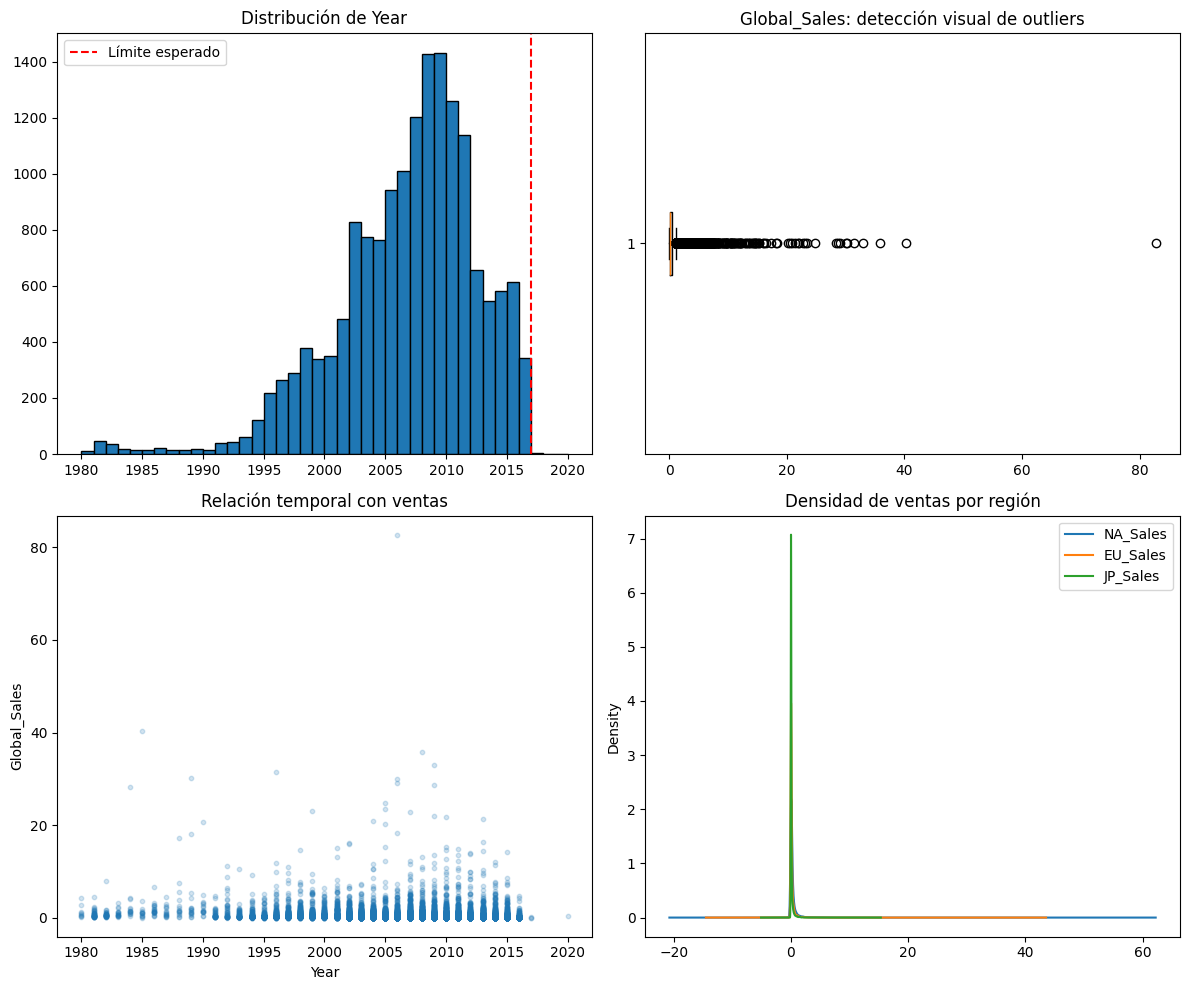

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histograma de Year
axes[0, 0].hist(df['Year'].dropna(), bins=40, edgecolor='black')
axes[0, 0].axvline(x=2017, color='r', linestyle='--', label='Límite esperado')
axes[0, 0].set_title('Distribución de Year')
axes[0, 0].legend()

# Boxplot de Global_Sales
axes[0, 1].boxplot(df['Global_Sales'].dropna(), vert=False)
axes[0, 1].set_title('Global_Sales: detección visual de outliers')

# Scatter Year vs Global_Sales
axes[1, 0].scatter(df['Year'], df['Global_Sales'], alpha=0.2, s=10)
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Global_Sales')
axes[1, 0].set_title('Relación temporal con ventas')

# Distribución de ventas regionales
df[['NA_Sales', 'EU_Sales', 'JP_Sales']].plot(kind='kde', ax=axes[1, 1])
axes[1, 1].set_title('Densidad de ventas por región')

plt.tight_layout()
plt.show()

#**6. Correlaciones preliminares**


Global_Sales    1.000000
NA_Sales        0.941047
EU_Sales        0.902836
Other_Sales     0.748331
JP_Sales        0.611816
Year           -0.074735
Name: Global_Sales, dtype: float64


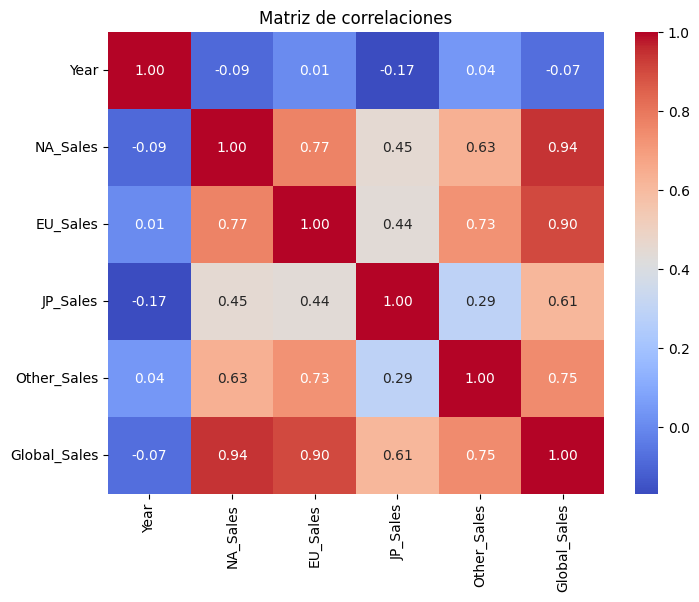

In [ ]:
corr_matrix = df[numeric_cols].corr()
print(corr_matrix['Global_Sales'].sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlaciones')
plt.show()

#**7. Variables categóricas: distribución y relación con ventas**

In [ ]:
# Frecuencia de Genre y Platform
print("\nTop 10 géneros por frecuencia:")
print(df['Genre'].value_counts().head(10))

print("\nTop 10 plataformas por frecuencia:")
print(df['Platform'].value_counts().head(10))

# Ventas promedio por género
genre_sales = df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)
print(f"\nVentas promedio por género:\n{genre_sales}")


Top 10 géneros por frecuencia:
Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Name: count, dtype: int64

Top 10 plataformas por frecuencia:
Platform
DS      2163
PS2     2161
PS3     1329
Wii     1325
X360    1265
PSP     1213
PS      1196
PC       960
XB       824
GBA      822
Name: count, dtype: int64

Ventas promedio por género:
Genre
Platform        0.938341
Shooter         0.791885
Role-Playing    0.623233
Racing          0.586101
Sports          0.567319
Fighting        0.529375
Action          0.528100
Misc            0.465762
Simulation      0.452364
Puzzle          0.420876
Strategy        0.257151
Adventure       0.185879
Name: Global_Sales, dtype: float64


# **Limpieza del dataset**


In [ ]:
df_clean = df.copy()

# 1. Filtrar Year válido: documentación Kaggle indica datos hasta 2016-2017
df_clean = df_clean[
    (df_clean['Year'].notna()) &
    (df_clean['Year'] >= 1980) &
    (df_clean['Year'] <= 2017)
].copy()

# 2. Eliminar filas con Global_Sales faltante o cero (sin información útil)
df_clean = df_clean[
    (df_clean['Global_Sales'].notna()) &
    (df_clean['Global_Sales'] > 0)
].copy()

# 3. Transformación logarítmica para normalizar distribución de ventas
df_clean['log_Global_Sales'] = np.log1p(df_clean['Global_Sales'])

# 4. Manejo de Publisher: top 20 + "Other"
top_pub = df_clean['Publisher'].value_counts().head(20).index
df_clean['Publisher_grp'] = df_clean['Publisher'].apply(
    lambda x: x if x in top_pub else 'Other'
)

print(f"Registros finales: {len(df_clean)} (original: {len(df)})")

Registros finales: 16326 (original: 16598)


* Year > 2017: eliminado por estar fuera del periodo de cobertura del dataset (fuente: documentación de Kaggle). Incluirlos introduciría error de medición temporal.
* Transformación log(Global_Sales): la distribución original presenta sesgo positivo extremo (media >> mediana). La transformación estabiliza varianza y mejora cumplimiento de supuestos de normalidad en residuos.
* Outliers en ventas: se mantienen tras transformación logarítmica porque representan éxitos comerciales reales, no errores de captura.

#**Especificación del Modelo MCO Adaptado**
Variable dependiente:
* log_Global_Sales: ventas globales en escala logarítmica (interpretación en términos porcentuales).

Variables explicativas base:
* NA_Sales, EU_Sales, JP_Sales: control por mercado regional.
* Year: tendencia temporal.
* Genre / Platform (dummies): efectos fijos por categoría.

#**Modelo base:**

$$log(Global_{Sales})_i = β₀ + β₁·NA_{Sales_i} + β₂·EU_{Sales_i} + β₃·JP_{Sales_i} + β₄·Year_i + u_i$$

# **Regresión Simple**

In [ ]:
# Modelo simple: log(Global_Sales) ~ NA_Sales
X_simple = sm.add_constant(df_clean['NA_Sales'])
y = df_clean['log_Global_Sales']

model_simple = sm.OLS(y, X_simple).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:       log_Global_Sales   R-squared:                       0.539
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                 1.906e+04
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:02:03   Log-Likelihood:                -1781.6
No. Observations:               16326   AIC:                             3567.
Df Residuals:                   16324   BIC:                             3583.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2131      0.002     96.024      0.0

                            OLS Regression Results                            
Dep. Variable:       log_Global_Sales   R-squared:                       0.539
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     55.46
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.00e-13
Time:                        02:02:03   Log-Likelihood:                -1781.6
No. Observations:               16326   AIC:                             3567.
Df Residuals:                   16324   BIC:                             3583.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2131      0.012     18.050      0.0

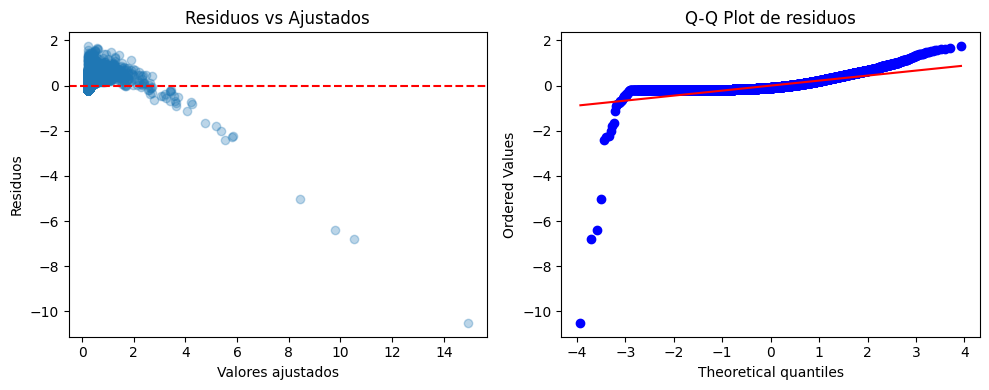

In [ ]:
import scipy.stats as stats

# 1. Errores estándar robustos (Huber-White)
model_robust = model_simple.get_robustcov_results(cov_type='HC1')
print(model_robust.summary())

# 2. Prueba de heterocedasticidad
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(model_simple.resid, model_simple.model.exog)
print(f"Breusch-Pagan p-valor: {bp_test[1]:.4f}")

# 3. Visualización de residuos
resid = model_simple.resid
fitted = model_simple.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(fitted, resid, alpha=0.3)
axes[0].axhline(0, color='r', linestyle='--')
axes[0].set_xlabel('Valores ajustados')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Ajustados')

stats.probplot(resid, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot de residuos')
plt.tight_layout()
plt.show()

# **Estimación de Modelo de Regresión Múltiple**
$$log(Global_{Sales_i})=β_0+β_1NA_{Sales_i}+β_2EU_{Sales_i}+β_3JP_{Sales_i}+β_4Year_i+u_i$$

In [ ]:
# Selección de variables explicativas
features_multi = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Year']
X_multi = sm.add_constant(df_clean[features_multi])
y = df_clean['log_Global_Sales']

# Estimación
model_multi = sm.OLS(y, X_multi).fit()
model_multi_robust = model_multi.get_robustcov_results(cov_type='HC1')

print(model_multi_robust.summary())

                            OLS Regression Results                            
Dep. Variable:       log_Global_Sales   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     187.6
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          1.64e-157
Time:                        02:02:03   Log-Likelihood:                -107.21
No. Observations:               16326   AIC:                             224.4
Df Residuals:                   16321   BIC:                             262.9
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.5879      0.997      9.619      0.0

## **Inferencia Estadística**

In [ ]:
# Intervalos de confianza al 95%
print("\nIntervalos de Confianza:")
print(model_multi_robust.conf_int(alpha=0.05))

# Prueba F global (significancia conjunta del modelo)
print(f"\nEstadístico F: {model_multi_robust.fvalue:.2f}")
print(f"P-valor F: {model_multi_robust.f_pvalue:.4f}")


Intervalos de Confianza:
[[ 7.63405455e+00  1.15416790e+01]
 [ 1.15875212e-01  2.56690137e-01]
 [ 1.09656195e-01  4.34623474e-01]
 [ 9.99059710e-02  3.21259239e-01]
 [-5.65443632e-03 -3.70227685e-03]]

Estadístico F: 187.63
P-valor F: 0.0000


# **Predicción**

In [ ]:
# Datos de entrada para la predicción
new_data = pd.DataFrame({
    'const': [1],
    'NA_Sales': [5.0],
    'EU_Sales': [4.0],
    'JP_Sales': [1.0],
    'Year': [2010]
})

# Predicción
pred = model_multi.get_prediction(new_data)
pred_summary = pred.summary_frame(alpha=0.05)

print("Predicción (Escala Log):", pred.predicted_mean[0])
print("Intervalo de Confianza 95% (Escala Log):")
print(pred_summary[['mean_ci_lower', 'mean_ci_upper']])

Predicción (Escala Log): 2.414925364961878
Intervalo de Confianza 95% (Escala Log):
   mean_ci_lower  mean_ci_upper
0       2.386283       2.443568


# **Inclusión de Variable Dicotómica (Dummy)**

In [ ]:
# Creación de la variable dummy
df_clean['Genre_Action'] = (df_clean['Genre'] == 'Action').astype(int)

# Actualizar variables explicativas
features_dummy = features_multi + ['Genre_Action']
X_dummy = sm.add_constant(df_clean[features_dummy])

# Estimación
model_dummy = sm.OLS(df_clean['log_Global_Sales'], X_dummy).fit()
model_dummy_robust = model_dummy.get_robustcov_results(cov_type='HC1')

print(model_dummy_robust.summary())

                            OLS Regression Results                            
Dep. Variable:       log_Global_Sales   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     165.3
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          4.53e-172
Time:                        02:02:03   Log-Likelihood:                -92.821
No. Observations:               16326   AIC:                             197.6
Df Residuals:                   16320   BIC:                             243.8
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           10.0210      0.979     10.241   